## 0. Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import mean_squared_error, f1_score, make_scorer
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMRegressor, LGBMClassifier

## 1. Load Data

In [4]:
train = pd.read_csv('Train.csv')
test  = pd.read_csv('Test.csv')

print('Train shape:', train.shape)
print('Test shape: ', test.shape)
train.head()

Train shape: (489, 12)
Test shape:  (48, 2)


,ID,team_id,country,team_code,confederation_name,region_name,tournament_id,tournament_name,year,matches_played,total_goals,stage_reached
0,WC-1930_ARG,T-03,Argentina,ARG,South American Football Confederation,South America,WC-1930,1930 FIFA Men's World Cup,1930,5,18,final
1,WC-1930_BEL,T-06,Belgium,BEL,Union of European Football Associations,Europe,WC-1930,1930 FIFA Men's World Cup,1930,2,0,group stage
2,WC-1930_BOL,T-07,Bolivia,BOL,South American Football Confederation,South America,WC-1930,1930 FIFA Men's World Cup,1930,2,0,group stage
3,WC-1930_BRA,T-09,Brazil,BRA,South American Football Confederation,South America,WC-1930,1930 FIFA Men's World Cup,1930,2,5,group stage
4,WC-1930_CHL,T-13,Chile,CHL,South American Football Confederation,South America,WC-1930,1930 FIFA Men's World Cup,1930,3,5,group stage


In [5]:
print(train.info())
print()
print('Missing values:')
print(train.isna().sum())
print()
print('Unique stage labels in train:')
print(train['stage_reached'].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 489 entries, 0 to 488
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  489 non-null    object
 1   team_id             489 non-null    object
 2   country             489 non-null    object
 3   team_code           489 non-null    object
 4   confederation_name  489 non-null    object
 5   region_name         489 non-null    object
 6   tournament_id       489 non-null    object
 7   tournament_name     489 non-null    object
 8   year                489 non-null    int64 
 9   matches_played      489 non-null    int64 
 10  total_goals         489 non-null    int64 
 11  stage_reached       489 non-null    object
dtypes: int64(3), object(9)
memory usage: 46.0+ KB
None

Missing values:
ID                    0
team_id               0
country               0
team_code             0
confederation_name    0
region_name           0
tourna

## 2. Stage Label Mapping

Train uses raw historical strings. Submission requires 7 classes:
`group | roundof32 | roundof16 | qf | sf | runnerup | champion`

Key decisions:
- `final round` / `second group stage` — pre-1986 formats; teams did not reach knockout rounds, treated as `group`
- `third-place match` — these teams lost the semi-final, so they are `sf`
- `final` — split into `champion` vs `runnerup` using tournament_standings.csv
- `roundof32` does not exist in history; it will be assigned at prediction time

In [6]:
STAGE_MAP = {
    'group stage':        'group',
    'final round':        'group',
    'second group stage': 'group',
    'round of 16':        'roundof16',
    'quarter-finals':     'qf',
    'semi-finals':        'sf',
    'third-place match':  'sf',
    'final':              'runnerup',  # placeholder; champion fixed below
}

train['Target'] = train['stage_reached'].map(STAGE_MAP)

# Fix champion: use tournament_standings to find position == 1 per tournament
standings = pd.read_csv('tournament_standings.csv')
champions = standings[standings['position'] == 1][['tournament_id', 'team_id']].copy()

train = train.merge(champions, on=['tournament_id', 'team_id'], how='left', indicator='_champ')
train.loc[train['_champ'] == 'both', 'Target'] = 'champion'
train = train.drop(columns=['_champ'])

print('Target class distribution:')
print(train['Target'].value_counts())
print()
print('Unmapped rows:', train['Target'].isna().sum())

Target class distribution:
Target
group        241
roundof16     95
qf            68
sf            42
champion      22
runnerup      21
Name: count, dtype: int64

Unmapped rows: 0


## 3. Exploratory Data Analysis

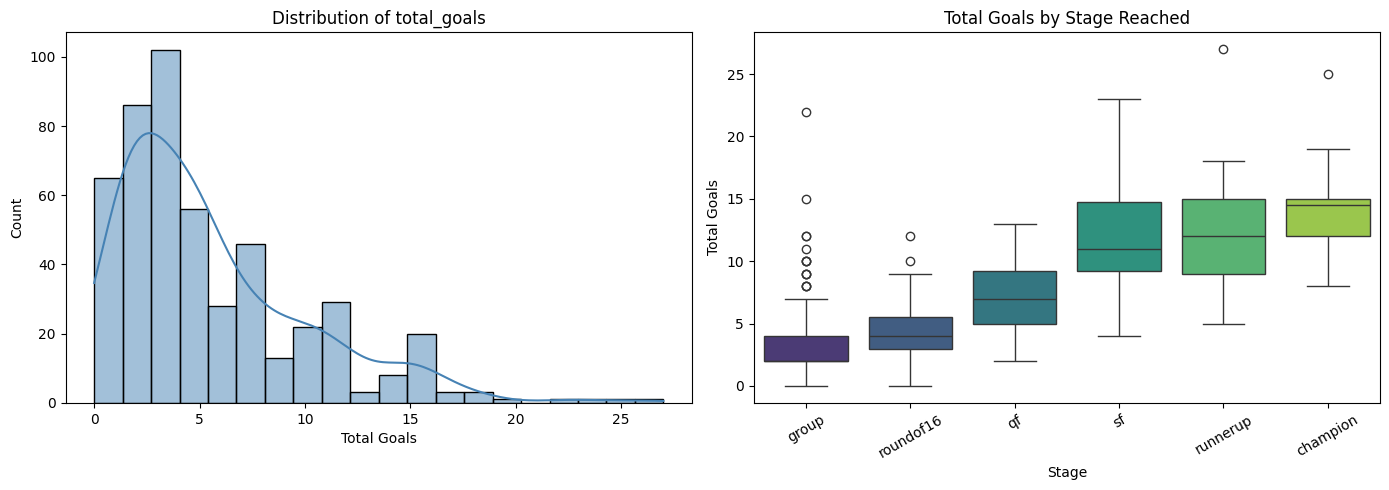

In [7]:
# Goals distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train['total_goals'], bins=20, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of total_goals')
axes[0].set_xlabel('Total Goals')

# Goals by stage — use mapped Target labels
stage_order = ['group', 'roundof16', 'qf', 'sf', 'runnerup', 'champion']
plot_data = train[train['Target'].isin(stage_order)]
sns.boxplot(x='Target', y='total_goals', data=plot_data,
            order=stage_order, palette='viridis', ax=axes[1])
axes[1].set_title('Total Goals by Stage Reached')
axes[1].set_xlabel('Stage')
axes[1].set_ylabel('Total Goals')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

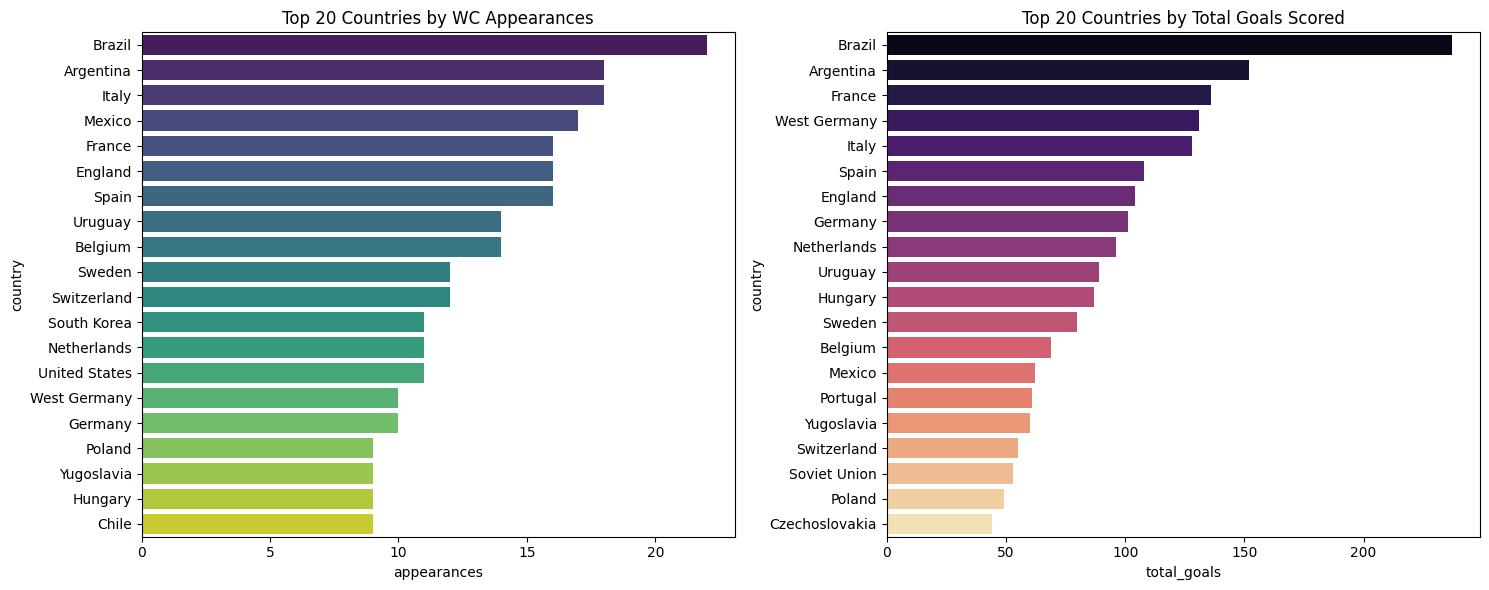

In [8]:
# Country appearances and scoring
appearances = train.groupby('country').size().sort_values(ascending=False).head(20).reset_index(name='appearances')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x='appearances', y='country', data=appearances, palette='viridis', ax=axes[0])
axes[0].set_title('Top 20 Countries by WC Appearances')

goals_by_country = train.groupby('country')['total_goals'].sum().sort_values(ascending=False).head(20).reset_index()
sns.barplot(x='total_goals', y='country', data=goals_by_country, palette='magma', ax=axes[1])
axes[1].set_title('Top 20 Countries by Total Goals Scored')

plt.tight_layout()
plt.show()

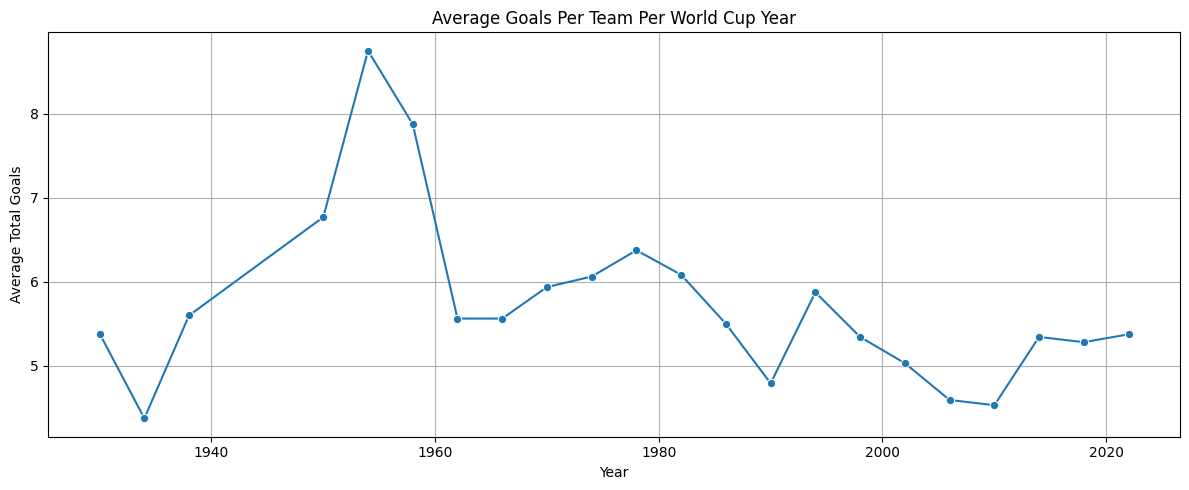

In [9]:
# Average goals per tournament year — trend over time
avg_goals_year = train.groupby('year')['total_goals'].mean().reset_index()
plt.figure(figsize=(12, 5))
sns.lineplot(x='year', y='total_goals', data=avg_goals_year, marker='o')
plt.title('Average Goals Per Team Per World Cup Year')
plt.xlabel('Year')
plt.ylabel('Average Total Goals')
plt.grid(True)
plt.tight_layout()
plt.show()

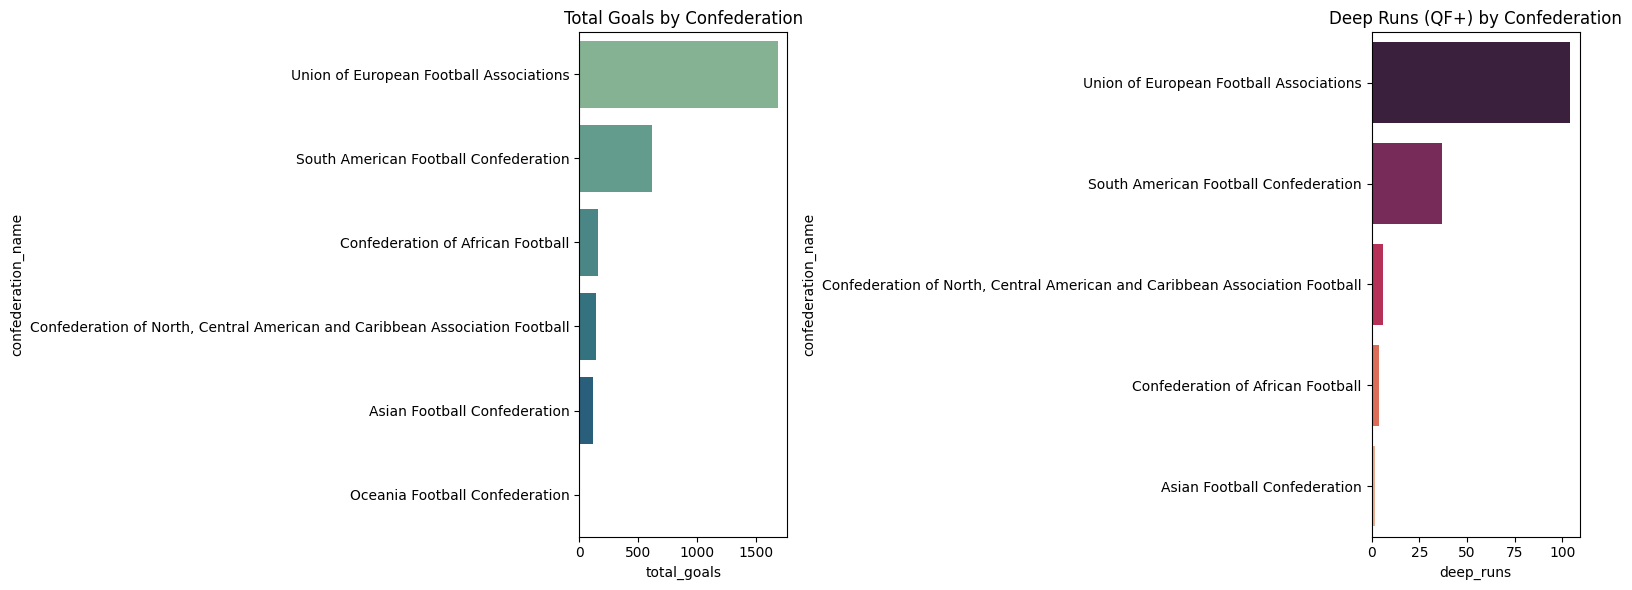

In [10]:
# Confederation breakdown: goals and deep runs
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

conf_goals = train.groupby('confederation_name')['total_goals'].sum().sort_values(ascending=False).reset_index()
sns.barplot(x='total_goals', y='confederation_name', data=conf_goals, palette='crest', ax=axes[0])
axes[0].set_title('Total Goals by Confederation')

deep_stages = ['qf', 'sf', 'runnerup', 'champion']
deep_runs = train[train['Target'].isin(deep_stages)]['confederation_name'].value_counts().reset_index()
deep_runs.columns = ['confederation_name', 'deep_runs']
sns.barplot(x='deep_runs', y='confederation_name', data=deep_runs, palette='rocket', ax=axes[1])
axes[1].set_title('Deep Runs (QF+) by Confederation')

plt.tight_layout()
plt.show()

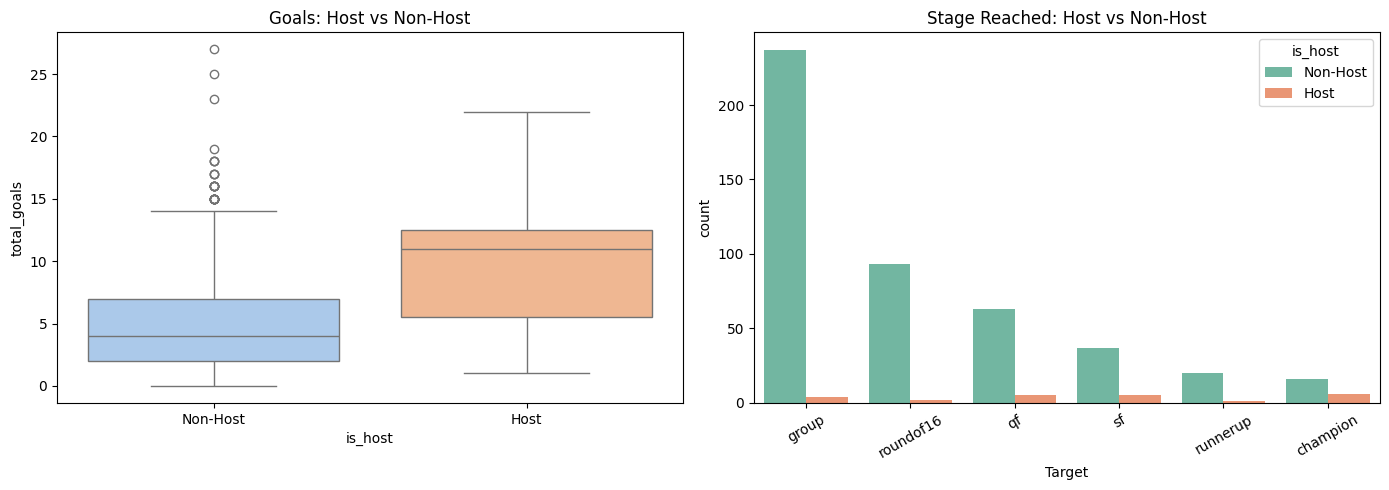

Average goals - Host: 9.65
Average goals - Non-Host: 5.36


In [11]:
# Host country advantage
host_countries = pd.read_csv('host_countries.csv')
host_countries = host_countries.rename(columns={'team_name': 'country'})
host_countries['year'] = host_countries['tournament_id'].str.extract(r'WC-(\d{4})').astype(int)

host_lookup = host_countries[['country', 'year']].drop_duplicates()

train_hosts = train.merge(host_lookup, on=['country', 'year'], how='left', indicator=True)
train_hosts['is_host'] = (train_hosts['_merge'] == 'both').astype(int)
train_hosts = train_hosts.drop(columns=['_merge'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x='is_host', y='total_goals', data=train_hosts, palette='pastel', ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Non-Host', 'Host'])
axes[0].set_title('Goals: Host vs Non-Host')

host_stage = train_hosts.groupby(['is_host', 'Target']).size().reset_index(name='count')
host_stage['is_host'] = host_stage['is_host'].map({0: 'Non-Host', 1: 'Host'})
sns.barplot(x='Target', y='count', hue='is_host', data=host_stage,
            order=stage_order, palette='Set2', ax=axes[1])
axes[1].set_title('Stage Reached: Host vs Non-Host')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print('Average goals - Host:', train_hosts[train_hosts['is_host']==1]['total_goals'].mean().round(2))
print('Average goals - Non-Host:', train_hosts[train_hosts['is_host']==0]['total_goals'].mean().round(2))

## 4. Feature Engineering

All historical aggregations use **expanding windows sorted chronologically** to prevent data leakage.
For each team appearing in tournament T, we only use data from tournaments before T.

> `matches_played` is intentionally excluded — it is determined by how far a team goes (leaks the target).

Cold-start teams (no prior WC history) receive confederation median values.

In [12]:
# Ordinal stage encoding for numeric aggregations
STAGE_ORDINAL = {
    'group':     0,
    'roundof32': 1,
    'roundof16': 2,
    'qf':        3,
    'sf':        4,
    'runnerup':  5,
    'champion':  6,
}

train['stage_num'] = train['Target'].map(STAGE_ORDINAL)

# Sort chronologically
train_sorted = train.sort_values('year').reset_index(drop=True)

In [13]:
def build_historical_features(df_sorted):
    """
    For each row (team x tournament), compute features from that team's
    prior tournaments only. No leakage from current or future rows.
    """
    records = []

    for idx, row in df_sorted.iterrows():
        team = row['team_id']
        current_year = row['year']

        # Prior rows for this team only
        prior = df_sorted[
            (df_sorted['team_id'] == team) &
            (df_sorted['year'] < current_year)
        ].sort_values('year')

        n = len(prior)

        feat = {
            'idx': idx,
            'appearances':              n,
            'is_debut':                 int(n == 0),
            'avg_goals':                prior['total_goals'].mean() if n > 0 else np.nan,
            'avg_goals_per_match':      (prior['total_goals'] / prior['matches_played']).mean() if n > 0 else np.nan,
            'avg_stage_num':            prior['stage_num'].mean() if n > 0 else np.nan,
            'best_stage_num':           prior['stage_num'].max() if n > 0 else np.nan,
            'last1_goals':              prior['total_goals'].iloc[-1] if n >= 1 else np.nan,
            'last2_goals':              prior['total_goals'].iloc[-2] if n >= 2 else np.nan,
            'last3_goals':              prior['total_goals'].iloc[-3] if n >= 3 else np.nan,
            'last1_stage_num':          prior['stage_num'].iloc[-1] if n >= 1 else np.nan,
            'last2_stage_num':          prior['stage_num'].iloc[-2] if n >= 2 else np.nan,
        }

        # Recency-weighted average goals (exponential weights, most recent = highest)
        if n > 0:
            weights = np.exp(np.linspace(0, 1, n))
            feat['recency_weighted_goals'] = np.average(prior['total_goals'], weights=weights)
            feat['recency_weighted_stage'] = np.average(prior['stage_num'], weights=weights)
        else:
            feat['recency_weighted_goals'] = np.nan
            feat['recency_weighted_stage'] = np.nan

        # Goal trend: slope of goals over last 3 appearances
        if n >= 3:
            recent = prior['total_goals'].values[-3:]
            feat['goal_trend'] = float(np.polyfit(range(3), recent, 1)[0])
        else:
            feat['goal_trend'] = np.nan

        records.append(feat)

    return pd.DataFrame(records).set_index('idx')


print('Building expanding-window historical features for train...')
hist_features_train = build_historical_features(train_sorted)
train_sorted = pd.concat([train_sorted, hist_features_train], axis=1)
print('Done. New feature columns:', list(hist_features_train.columns))

Building expanding-window historical features for train...
Done. New feature columns: ['appearances', 'is_debut', 'avg_goals', 'avg_goals_per_match', 'avg_stage_num', 'best_stage_num', 'last1_goals', 'last2_goals', 'last3_goals', 'last1_stage_num', 'last2_stage_num', 'recency_weighted_goals', 'recency_weighted_stage', 'goal_trend']


In [14]:
# Host flag for train
train_sorted = train_sorted.merge(host_lookup, on=['country', 'year'], how='left', indicator=True)
train_sorted['is_host'] = (train_sorted['_merge'] == 'both').astype(int)
train_sorted = train_sorted.drop(columns=['_merge'])

# Confederation label encoding
le_conf = LabelEncoder()
train_sorted['conf_encoded'] = le_conf.fit_transform(train_sorted['confederation_name'])

print('is_host distribution:', train_sorted['is_host'].value_counts().to_dict())
print('Confederations encoded:', dict(zip(le_conf.classes_, le_conf.transform(le_conf.classes_))))

is_host distribution: {0: 466, 1: 23}
Confederations encoded: {'Asian Football Confederation': np.int64(0), 'Confederation of African Football': np.int64(1), 'Confederation of North, Central American and Caribbean Association Football': np.int64(2), 'Oceania Football Confederation': np.int64(3), 'South American Football Confederation': np.int64(4), 'Union of European Football Associations': np.int64(5)}


In [15]:
# Cold-start imputation: use confederation median for teams with no prior history
conf_medians = train_sorted.groupby('confederation_name').agg(
    avg_goals_median=('avg_goals', 'median'),
    avg_stage_median=('avg_stage_num', 'median'),
    avg_gpm_median=('avg_goals_per_match', 'median'),
).reset_index()

train_sorted = train_sorted.merge(conf_medians, on='confederation_name', how='left')

fill_with_conf = {
    'avg_goals':             'avg_goals_median',
    'avg_goals_per_match':   'avg_gpm_median',
    'avg_stage_num':         'avg_stage_median',
    'best_stage_num':        'avg_stage_median',
    'recency_weighted_goals':'avg_goals_median',
    'recency_weighted_stage':'avg_stage_median',
    'last1_goals':           'avg_goals_median',
    'last2_goals':           'avg_goals_median',
    'last3_goals':           'avg_goals_median',
    'last1_stage_num':       'avg_stage_median',
    'last2_stage_num':       'avg_stage_median',
    'goal_trend':            'avg_goals_median',
}

for feat_col, median_col in fill_with_conf.items():
    train_sorted[feat_col] = train_sorted[feat_col].fillna(train_sorted[median_col])

train_sorted = train_sorted.drop(columns=['avg_goals_median', 'avg_stage_median', 'avg_gpm_median'])

print('Missing values after cold-start imputation:')
print(train_sorted[list(fill_with_conf.keys())].isna().sum())

Missing values after cold-start imputation:
avg_goals                 0
avg_goals_per_match       0
avg_stage_num             0
best_stage_num            0
recency_weighted_goals    0
recency_weighted_stage    0
last1_goals               0
last2_goals               0
last3_goals               0
last1_stage_num           0
last2_stage_num           0
goal_trend                0
dtype: int64


In [16]:
# Feature columns used for both models
FEATURE_COLS = [
    'appearances', 'is_debut', 'is_host',
    'avg_goals', 'avg_goals_per_match',
    'avg_stage_num', 'best_stage_num',
    'last1_goals', 'last2_goals', 'last3_goals',
    'last1_stage_num', 'last2_stage_num',
    'recency_weighted_goals', 'recency_weighted_stage',
    'goal_trend',
    'conf_encoded',
]

def clean_col_names(df):
    df.columns = df.columns.str.replace(' ', '_').str.lower()
    return df

X_train = train_sorted[FEATURE_COLS].copy()
y_goals  = train_sorted['total_goals'].copy()
y_stage  = train_sorted['Target'].copy()

# Encode stage target as integer for classifiers
le_stage = LabelEncoder()
y_stage_enc = le_stage.fit_transform(y_stage)

print('Feature matrix shape:', X_train.shape)
print('Stage classes:', list(le_stage.classes_))
print('Any NaNs in features:', X_train.isna().sum().sum())

Feature matrix shape: (489, 16)
Stage classes: ['champion', 'group', 'qf', 'roundof16', 'runnerup', 'sf']
Any NaNs in features: 0


## 5. Build Test Features

For the 48 test teams we use ALL of their historical data (no holdout needed for test).

In [17]:
def build_test_features(test_df, train_full):
    """
    For each test team, aggregate all available historical rows from train_full.
    Cold-start teams get confederation median imputation.
    """
    # Map test country to team_id and confederation using train
    country_meta = train_full[['country', 'team_id', 'confederation_name']].drop_duplicates('country')
    test_df = test_df.merge(country_meta, on='country', how='left')

    # 2026 host nations
    HOST_2026 = {'United States', 'Canada', 'Mexico'}
    test_df['is_host'] = test_df['country'].isin(HOST_2026).astype(int)
    test_df['year'] = 2026

    records = []
    for _, row in test_df.iterrows():
        team = row['team_id']
        prior = train_full[train_full['team_id'] == team].sort_values('year')
        n = len(prior)

        feat = {
            'ID':          row['ID'],
            'country':     row['country'],
            'confederation_name': row['confederation_name'],
            'is_host':     row['is_host'],
            'appearances': n,
            'is_debut':    int(n == 0),
            'avg_goals':              prior['total_goals'].mean() if n > 0 else np.nan,
            'avg_goals_per_match':    (prior['total_goals'] / prior['matches_played']).mean() if n > 0 else np.nan,
            'avg_stage_num':          prior['stage_num'].mean() if n > 0 else np.nan,
            'best_stage_num':         prior['stage_num'].max() if n > 0 else np.nan,
            'last1_goals':            prior['total_goals'].iloc[-1] if n >= 1 else np.nan,
            'last2_goals':            prior['total_goals'].iloc[-2] if n >= 2 else np.nan,
            'last3_goals':            prior['total_goals'].iloc[-3] if n >= 3 else np.nan,
            'last1_stage_num':        prior['stage_num'].iloc[-1] if n >= 1 else np.nan,
            'last2_stage_num':        prior['stage_num'].iloc[-2] if n >= 2 else np.nan,
        }

        if n > 0:
            weights = np.exp(np.linspace(0, 1, n))
            feat['recency_weighted_goals'] = np.average(prior['total_goals'], weights=weights)
            feat['recency_weighted_stage'] = np.average(prior['stage_num'], weights=weights)
        else:
            feat['recency_weighted_goals'] = np.nan
            feat['recency_weighted_stage'] = np.nan

        if n >= 3:
            recent = prior['total_goals'].values[-3:]
            feat['goal_trend'] = float(np.polyfit(range(3), recent, 1)[0])
        else:
            feat['goal_trend'] = np.nan

        records.append(feat)

    test_features = pd.DataFrame(records)

    # Confederation median imputation for cold-start teams
    test_features = test_features.merge(conf_medians, on='confederation_name', how='left')
    # Use the existing fill_with_conf dictionary for correct column mapping
    for feat_col, median_col in fill_with_conf.items():
        test_features[feat_col] = test_features[feat_col].fillna(test_features[median_col])

    test_features = test_features.drop(columns=[c for c in test_features.columns if '_median' in c])

    test_features['confederation_name'] = test_features['confederation_name'].fillna('Unknown Confederation')
    known_classes = list(le_conf.classes_)
    test_features['confederation_name'] = test_features['confederation_name'].apply(
        lambda x: x if x in known_classes else known_classes[0]
    )
    test_features['conf_encoded'] = le_conf.transform(test_features['confederation_name'])

    return test_features


test_features = build_test_features(test.copy(), train_sorted)
X_test = test_features[FEATURE_COLS].copy()

print('Test feature matrix shape:', X_test.shape)
print('Cold-start / debut teams:')
print(test_features[test_features['is_debut'] == 1][['country', 'confederation_name']].to_string(index=False))

Test feature matrix shape: (48, 16)
Cold-start / debut teams:
      country           confederation_name
      Czechia Asian Football Confederation
      Turkiye Asian Football Confederation
   Cabo Verde Asian Football Confederation
Cote d'Ivoire Asian Football Confederation
     DR Congo Asian Football Confederation
       Jordan Asian Football Confederation
   Uzbekistan Asian Football Confederation
      Curacao Asian Football Confederation


## 6. Leave-One-Tournament-Out Cross-Validation

Groups = tournament_id. Each fold holds out one entire tournament.
Last fold (2022) is the most informative proxy for 2026 performance.

In [18]:
groups = train_sorted['tournament_id'].values
logo = LeaveOneGroupOut()

X_train_clean = clean_col_names(X_train)
X_test_clean  = clean_col_names(X_test)

print('LOTO groups (number of tournaments):', len(np.unique(groups)))

LOTO groups (number of tournaments): 22


## 7. Regression — Predict total_goals

In [19]:
regression_models = {
    'Ridge':                    Ridge(alpha=1.0),
    'Random Forest Regressor':  RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42),
    'LGBM Regressor':           LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
}

regression_rmse_scores = {}

for name, model in regression_models.items():
    fold_rmse = []
    for train_idx, val_idx in logo.split(X_train_clean, y_goals, groups=groups):
        Xf_tr, Xf_val = X_train_clean.iloc[train_idx], X_train_clean.iloc[val_idx]
        yf_tr, yf_val = y_goals.iloc[train_idx],       y_goals.iloc[val_idx]
        model.fit(Xf_tr, yf_tr)
        preds = model.predict(Xf_val)
        fold_rmse.append(np.sqrt(mean_squared_error(yf_val, preds)))
    regression_rmse_scores[name] = np.mean(fold_rmse)
    print(f'{name}: RMSE = {regression_rmse_scores[name]:.4f}')

best_reg_name = min(regression_rmse_scores, key=regression_rmse_scores.get)
print(f'\nBest regression model: {best_reg_name} (RMSE {regression_rmse_scores[best_reg_name]:.4f})')

Ridge: RMSE = 4.0728
Random Forest Regressor: RMSE = 4.2336
Gradient Boosting Regressor: RMSE = 4.2471
LGBM Regressor: RMSE = 4.4417

Best regression model: Ridge (RMSE 4.0728)


## 8. Classification — Predict stage_reached

In [20]:
classification_models = {
    'Logistic Regression':        LogisticRegression(random_state=42, n_jobs=-1, max_iter=1000),
    'Random Forest Classifier':   RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting Classifier': GradientBoostingClassifier(random_state=42),
    'LGBM Classifier':            LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
}

classification_f1_scores = {}

for name, model in classification_models.items():
    fold_f1 = []
    for train_idx, val_idx in logo.split(X_train_clean, y_stage_enc, groups=groups):
        Xf_tr, Xf_val = X_train_clean.iloc[train_idx], X_train_clean.iloc[val_idx]
        yf_tr, yf_val = y_stage_enc[train_idx],        y_stage_enc[val_idx]
        model.fit(Xf_tr, yf_tr)
        preds = model.predict(Xf_val)
        fold_f1.append(f1_score(yf_val, preds, average='weighted', zero_division=0))
    classification_f1_scores[name] = np.mean(fold_f1)
    print(f'{name}: F1 = {classification_f1_scores[name]:.4f}')

best_clf_name = max(classification_f1_scores, key=classification_f1_scores.get)
print(f'\nBest classification model: {best_clf_name} (F1 {classification_f1_scores[best_clf_name]:.4f})')

Logistic Regression: F1 = 0.4097
Random Forest Classifier: F1 = 0.3853
Gradient Boosting Classifier: F1 = 0.3798
LGBM Classifier: F1 = 0.3690

Best classification model: Logistic Regression (F1 0.4097)


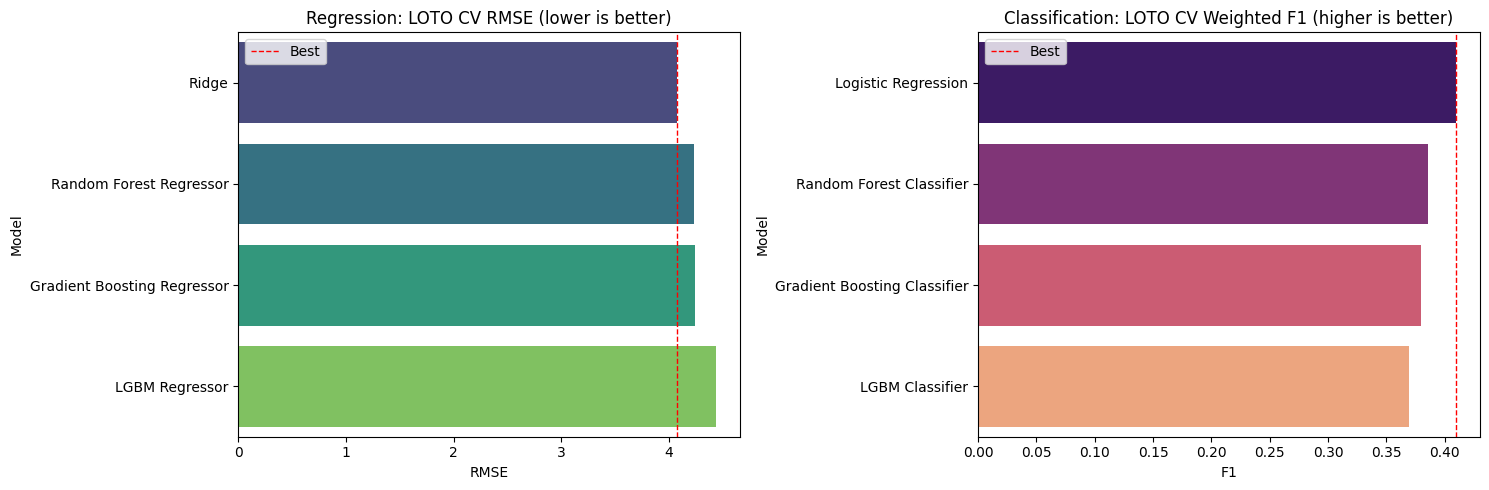

In [21]:
# Model comparison plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

reg_df = pd.DataFrame(list(regression_rmse_scores.items()), columns=['Model', 'RMSE'])
sns.barplot(x='RMSE', y='Model', data=reg_df.sort_values('RMSE'), palette='viridis', ax=axes[0])
axes[0].set_title('Regression: LOTO CV RMSE (lower is better)')
axes[0].axvline(reg_df['RMSE'].min(), color='red', linestyle='--', linewidth=1, label='Best')
axes[0].legend()

clf_df = pd.DataFrame(list(classification_f1_scores.items()), columns=['Model', 'F1'])
sns.barplot(x='F1', y='Model', data=clf_df.sort_values('F1', ascending=False), palette='magma', ax=axes[1])
axes[1].set_title('Classification: LOTO CV Weighted F1 (higher is better)')
axes[1].axvline(clf_df['F1'].max(), color='red', linestyle='--', linewidth=1, label='Best')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Hyperparameter Tuning with RandomizedSearchCV

Using `RandomizedSearchCV` instead of `GridSearchCV` — much faster on small data with many parameters.
Tune the best model from each task.

In [22]:
# Regression tuning
param_dist_gbr = {
    'n_estimators':    [100, 200, 300, 400],
    'learning_rate':   [0.01, 0.05, 0.1, 0.2],
    'max_depth':       [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'subsample':       [0.7, 0.8, 1.0],
}

gbr_base = GradientBoostingRegressor(random_state=42)

rs_gbr = RandomizedSearchCV(
    estimator=gbr_base,
    param_distributions=param_dist_gbr,
    n_iter=60,
    scoring='neg_mean_squared_error',
    cv=logo,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

rs_gbr.fit(X_train_clean, y_goals, groups=groups)

print('Best regression params:', rs_gbr.best_params_)
print(f'Best regression RMSE:   {-rs_gbr.best_score_:.4f}')

best_regressor = rs_gbr.best_estimator_

Fitting 22 folds for each of 60 candidates, totalling 1320 fits
Best regression params: {'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 5, 'learning_rate': 0.01}
Best regression RMSE:   18.7570


In [23]:
# Classification tuning
param_dist_gbc = {
    'n_estimators':    [100, 200, 300, 400],
    'learning_rate':   [0.01, 0.05, 0.1, 0.2],
    'max_depth':       [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'subsample':       [0.7, 0.8, 1.0],
}

f1_scorer = make_scorer(f1_score, average='weighted', zero_division=0)

gbc_base = GradientBoostingClassifier(random_state=42)

rs_gbc = RandomizedSearchCV(
    estimator=gbc_base,
    param_distributions=param_dist_gbc,
    n_iter=60,
    scoring=f1_scorer,
    cv=logo,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

rs_gbc.fit(X_train_clean, y_stage_enc, groups=groups)

print('Best classification params:', rs_gbc.best_params_)
print(f'Best classification F1:     {rs_gbc.best_score_:.4f}')

best_classifier = rs_gbc.best_estimator_

Fitting 22 folds for each of 60 candidates, totalling 1320 fits
Best classification params: {'subsample': 1.0, 'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 2, 'learning_rate': 0.01}
Best classification F1:     0.4241


## 10. Retrain on Full Data and Generate Predictions

In [25]:
best_regressor.fit(X_train_clean, y_goals)
best_classifier.fit(X_train_clean, y_stage_enc)

# Before prediction, check for and fill any remaining NaNs in X_test_clean
if X_test_clean.isnull().sum().sum() > 0:
    print("WARNING: X_test_clean still contains NaNs. Imputing with training medians.")
    # Calculate medians from the training data
    # FEATURE_COLS is assumed to be available from a previous cell
    train_medians = X_train_clean.median()

    # Impute NaNs in X_test_clean with these medians
    X_test_clean = X_test_clean.fillna(train_medians)
    print("NaNs after imputation:", X_test_clean.isnull().sum().sum())

# Regression predictions — clip to non-negative integers
goal_preds_raw = best_regressor.predict(X_test_clean)
goal_preds = np.maximum(0, np.round(goal_preds_raw)).astype(int)

# Classification predictions — decode back to stage strings
stage_preds_enc = best_classifier.predict(X_test_clean)
stage_preds = le_stage.inverse_transform(stage_preds_enc)

print('Goal predictions range:', goal_preds.min(), '–', goal_preds.max())
print('Stage prediction distribution:')
print(pd.Series(stage_preds).value_counts())

NaNs after imputation: 0
Goal predictions range: 3 – 10
Stage prediction distribution:
group        33
roundof16    11
qf            4
Name: count, dtype: int64


## 11. Post-Processing — Enforce Tournament Bracket Constraints

The 2026 WC has fixed numbers per stage:
- `champion`: exactly 1
- `runnerup`: exactly 1
- `sf`: exactly 2 (semi-final losers)
- `qf`: exactly 4
- `roundof16`: exactly 8
- `roundof32`: exactly 16 (new stage — group runners-up who lose R32)
- `group`: exactly 16 (bottom teams from groups)

We build a `strength_score` per team from predicted goals + predicted stage ordinal,
then rank all 48 teams and assign stages from top down.

In [26]:
# Predicted stage probabilities for ranking confidence
stage_proba = best_classifier.predict_proba(X_test_clean)

# Ordinal expected stage from probabilities
stage_classes_ord = np.array([STAGE_ORDINAL.get(c, 0) for c in le_stage.classes_])
expected_stage_score = stage_proba @ stage_classes_ord

# Composite strength score: 50% normalised goals + 50% expected stage ordinal
norm_goals  = (goal_preds_raw - goal_preds_raw.min()) / (goal_preds_raw.max() - goal_preds_raw.min() + 1e-9)
norm_stage  = (expected_stage_score - expected_stage_score.min()) / (expected_stage_score.max() - expected_stage_score.min() + 1e-9)
strength    = 0.5 * norm_goals + 0.5 * norm_stage

# Build submission frame with ranking
submission = pd.DataFrame({
    'ID':       test_features['ID'].values,
    'country':  test_features['country'].values,
    'total_goals': goal_preds,
    'strength': strength,
})

# Rank teams by strength (descending)
submission = submission.sort_values('strength', ascending=False).reset_index(drop=True)
submission['rank'] = submission.index + 1

# Assign bracket slots — 2026 WC format (48 teams)
def assign_stage_by_rank(rank):
    if rank == 1:        return 'champion'
    elif rank == 2:      return 'runnerup'
    elif rank <= 4:      return 'sf'
    elif rank <= 8:      return 'qf'
    elif rank <= 16:     return 'roundof16'
    elif rank <= 32:     return 'roundof32'
    else:                return 'group'

submission['Target'] = submission['rank'].apply(assign_stage_by_rank)

print('Stage assignment distribution:')
print(submission['Target'].value_counts())
print()
print('Top 10 teams by predicted strength:')
print(submission[['rank', 'country', 'total_goals', 'Target']].head(10).to_string(index=False))

Stage assignment distribution:
Target
group        16
roundof32    16
roundof16     8
qf            4
sf            2
runnerup      1
champion      1
Name: count, dtype: int64

Top 10 teams by predicted strength:
 rank     country  total_goals    Target
    1      Brazil           10  champion
    2      France            9  runnerup
    3   Argentina            8        sf
    4     England            8        sf
    5       Spain            7        qf
    6 Netherlands            7        qf
    7     Belgium            7        qf
    8     Uruguay            7        qf
    9    Portugal            6 roundof16
   10      Sweden            6 roundof16


## 12. Sanity Checks

In [ ]:
# Check 1: correct number of teams per stage
expected_counts = {
    'champion': 1, 'runnerup': 1, 'sf': 2, 'qf': 4,
    'roundof16': 8, 'roundof32': 16, 'group': 16
}

actual_counts = submission['Target'].value_counts().to_dict()

print('Stage count check (expected vs actual):')
all_ok = True
for stage, exp in expected_counts.items():
    act = actual_counts.get(stage, 0)
    status = 'OK' if act == exp else 'MISMATCH'
    if status == 'MISMATCH':
        all_ok = False
    print(f'  {stage:12s}: expected {exp:2d}, got {act:2d} [{status}]')

print()
if all_ok:
    print('All stage counts correct.')
else:
    print('WARNING: stage counts do not match expected bracket.')

# Check 2: total teams = 48
print(f'\nTotal teams in submission: {len(submission)} (expected 48)')

# Check 3: champion predicted goals should be among the highest
champion_goals = submission[submission['Target'] == 'champion']['total_goals'].values[0]
print(f'\nChampion predicted goals: {champion_goals}')
print(f'Submission goals range: {submission["total_goals"].min()} – {submission["total_goals"].max()}')

In [ ]:
# Visualise final predictions
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Goals by predicted stage
stage_ord_list = ['group', 'roundof32', 'roundof16', 'qf', 'sf', 'runnerup', 'champion']

sns.boxplot(
    x='Target', y='total_goals', data=submission,
    order=stage_ord_list, palette='viridis', ax=axes[0]
)
axes[0].set_title('Predicted Goals by Predicted Stage')
axes[0].set_xlabel('Predicted Stage')
axes[0].set_ylabel('Predicted Total Goals')
axes[0].tick_params(axis='x', rotation=30)

# Top 20 teams by predicted goals
top20 = submission.nlargest(20, 'total_goals')[['country', 'total_goals', 'Target']]
colors_map = {
    'champion': '#FFD700', 'runnerup': '#C0C0C0', 'sf': '#CD7F32',
    'qf': '#4CAF50', 'roundof16': '#2196F3', 'roundof32': '#9C27B0', 'group': '#607D8B'
}
colors = [colors_map.get(t, '#000000') for t in top20['Target']]

axes[1].barh(range(len(top20)), top20['total_goals'].values, color=colors)
axes[1].set_yticks(range(len(top20)))
axes[1].set_yticklabels(top20['country'].values, fontsize=9)
axes[1].set_title('Top 20 Teams by Predicted Goals')
axes[1].set_xlabel('Predicted Total Goals')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FFD700', label='champion'),
    Patch(facecolor='#C0C0C0', label='runnerup'),
    Patch(facecolor='#CD7F32', label='sf'),
    Patch(facecolor='#4CAF50', label='qf'),
    Patch(facecolor='#2196F3', label='roundof16'),
    Patch(facecolor='#9C27B0', label='roundof32'),
    Patch(facecolor='#607D8B', label='group'),
]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

## 13. Save Submission

In [ ]:
final_submission = submission[['ID', 'total_goals', 'Target']].copy()

# Restore original test row order
final_submission = final_submission.set_index('ID').loc[test['ID']].reset_index()

final_submission.to_csv('submission.csv', index=False)

print('Submission saved: submission.csv')
print(f'Rows: {len(final_submission)}')
print()
print(final_submission.head(10).to_string(index=False))